<a href="https://colab.research.google.com/github/mhabibier/scikit-learn-cookbook/blob/main/08_Tree_Based_Algorithms_and_Ensemble_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8 — Tree-Based Algorithms and Ensemble Methods

**scikit-learn Cookbook, Third Edition — John Sukup (Packt, 2025)**  
**Nama:** Muhammad Habibie Rabbani · **Kelas:** TK-47-04

## Tujuan pembelajaran
Memahami pemisahan rekursif pada decision tree, pengurangan varians melalui bagging/Random Forest, boosting bertahap, stacking, serta pemilihan hyperparameter dan interpretasi feature importance.

## Peta reproduksi
Notebook ini mengadaptasi notebook bab utama dan *Exercise Solutions* dari [kode pendamping resmi](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500), commit `c624b1279cf23a83273e806cede15cad0c9e5500`. Penjelasan ditulis ulang dalam Bahasa Indonesia; kode disesuaikan agar dapat dijalankan pada lingkungan yang dicatat di bawah. Penomoran bagian mengikuti alur konsep sumber, bukan nomor halaman PDF. Buku tetap referensi utama untuk membaca uraian lengkap.

| Resep sumber | Bagian |
|---|---|
| Introduction to decision trees | 1 |
| Random Forests and bagging | 2 |
| Gradient Boosted Machines | 3 |
| Hyperparameter tuning | 4 |
| Comparing ensembles (RF, GB, stacking) | 5 |
| Exercises 1–3 (Wine, Cancer, Digits) | 6–8 |

## Penyesuaian dan batas reproduksi
Heading sumber utama keliru menyebut SVM; judul diperbaiki sesuai isi dan nama file. Stratifikasi ditambahkan, semua seed eksplisit, dan bagging diperagakan tersendiri. Parameter GBM sumber (1.000 trees, learning_rate 0,2) tetap ditunjukkan sebagai demonstrasi. Heatmap tuning menahan learning rate tetap agar tidak mencampur beberapa eksperimen. Nilai feature importance tidak ditafsirkan sebagai sebab akibat.

## Cara menjalankan
Jalankan **Restart Kernel → Run All** dari atas ke bawah. Setiap notebook mandiri. Gunakan Python 3.12 dan paket dalam `requirements.txt`; versi yang benar-benar dipakai tampil di sel pertama. Dataset tersedia melalui scikit-learn atau generator sintetis; tidak memerlukan unduhan data tambahan setelah paket terpasang.

Untuk Google Colab: unggah `.ipynb`, instal versi paket yang diperlukan bila berbeda, lalu **Restart session → Run all**. Pengujian paket ini dilakukan dengan proses IPython baru per notebook, bukan melalui antarmuka Colab.

In [1]:
%matplotlib inline
import sys, platform, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score

SEED = 2024
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (8, 4.5), 'figure.dpi': 115, 'axes.titlesize': 12})
pd.set_option('display.max_columns', 16)
pd.set_option('display.precision', 4)
print({'Python': platform.python_version(), 'scikit-learn': sklearn.__version__,
       'NumPy': np.__version__, 'pandas': pd.__version__, 'seed': SEED})

def audit_numeric(X, y=None, name='data'):
    frame = pd.DataFrame(X)
    print(name, {'shape': frame.shape, 'missing': int(frame.isna().sum().sum()),
                 'duplicate_rows': int(frame.duplicated().sum()),
                 'all_finite': bool(np.isfinite(frame.to_numpy(dtype=float)).all())})
    if y is not None and np.asarray(y).ndim == 1:
        display(pd.Series(y).value_counts().sort_index().rename('jumlah').to_frame())

def report(y_true, y_pred, names=None):
    result = classification_report(y_true, y_pred, target_names=names, output_dict=True, zero_division=0)
    overall_accuracy = result.pop('accuracy', None)
    display(pd.DataFrame(result).T)
    if overall_accuracy is not None:
        print(f'Overall accuracy: {overall_accuracy:.4f} (n={len(y_true)})')

def metrics(y_true, y_pred):
    return {'accuracy': accuracy_score(y_true, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0)}

{'Python': '3.13.16', 'scikit-learn': '1.6.1', 'NumPy': '2.1.3', 'pandas': '2.2.3', 'seed': 2024}


## 1. Decision tree: impurity, split dan overfitting
Decision tree membagi ruang fitur secara rekursif dengan aturan seperti `petal width <= threshold`. Pada klasifikasi, sebuah node memiliki proporsi kelas $p_k$. **Gini impurity** adalah $G=1-\sum_kp_k^2$, sedangkan **entropy** adalah $H=-\sum_k p_k\log p_k$. Split dipilih secara greedy untuk menurunkan impurity berbobot ukuran anak node. Daun memprediksi kelas mayoritas atau proporsi kelas di daun.

Pohon yang terlalu dalam dapat menghafal training dan memiliki varians tinggi. `max_depth`, `min_samples_leaf`, dan pruning `ccp_alpha` mengendalikan kompleksitas. Pencarian greedy tidak menjamin pohon optimal secara global. Untuk fitur numerik, scaling biasanya tidak diperlukan karena urutan nilai tetap sama pada transformasi monoton; model pohon tetap perlu encoding untuk fitur kategorikal pada implementasi ini.

Iris adalah dataset kecil dengan 150 observasi dan tiga kelas. Audit memeriksa kondisi data, bukan otomatis membuang duplikasi atau outlier. Pengamatan duplikat dapat mewakili objek berbeda dengan pengukuran sama; data yang berasal dari subjek sama perlu group split bila identitas tersedia.

Iris {'shape': (150, 4), 'missing': 0, 'duplicate_rows': 1, 'all_finite': True}


,jumlah
0,50
1,50
2,50


{'depth': 5, 'leaves': np.int64(8), 'training_accuracy': 1.0, 'accuracy': 0.9111111111111111, 'balanced_accuracy': np.float64(0.9111111111111111), 'macro_f1': 0.9111111111111111}


,precision,recall,f1-score,support
setosa,1.0000,1.0000,1.0000,15.0
versicolor,0.8667,0.8667,0.8667,15.0
virginica,0.8667,0.8667,0.8667,15.0
macro avg,0.9111,0.9111,0.9111,45.0
weighted avg,0.9111,0.9111,0.9111,45.0


Overall accuracy: 0.9111 (n=45)


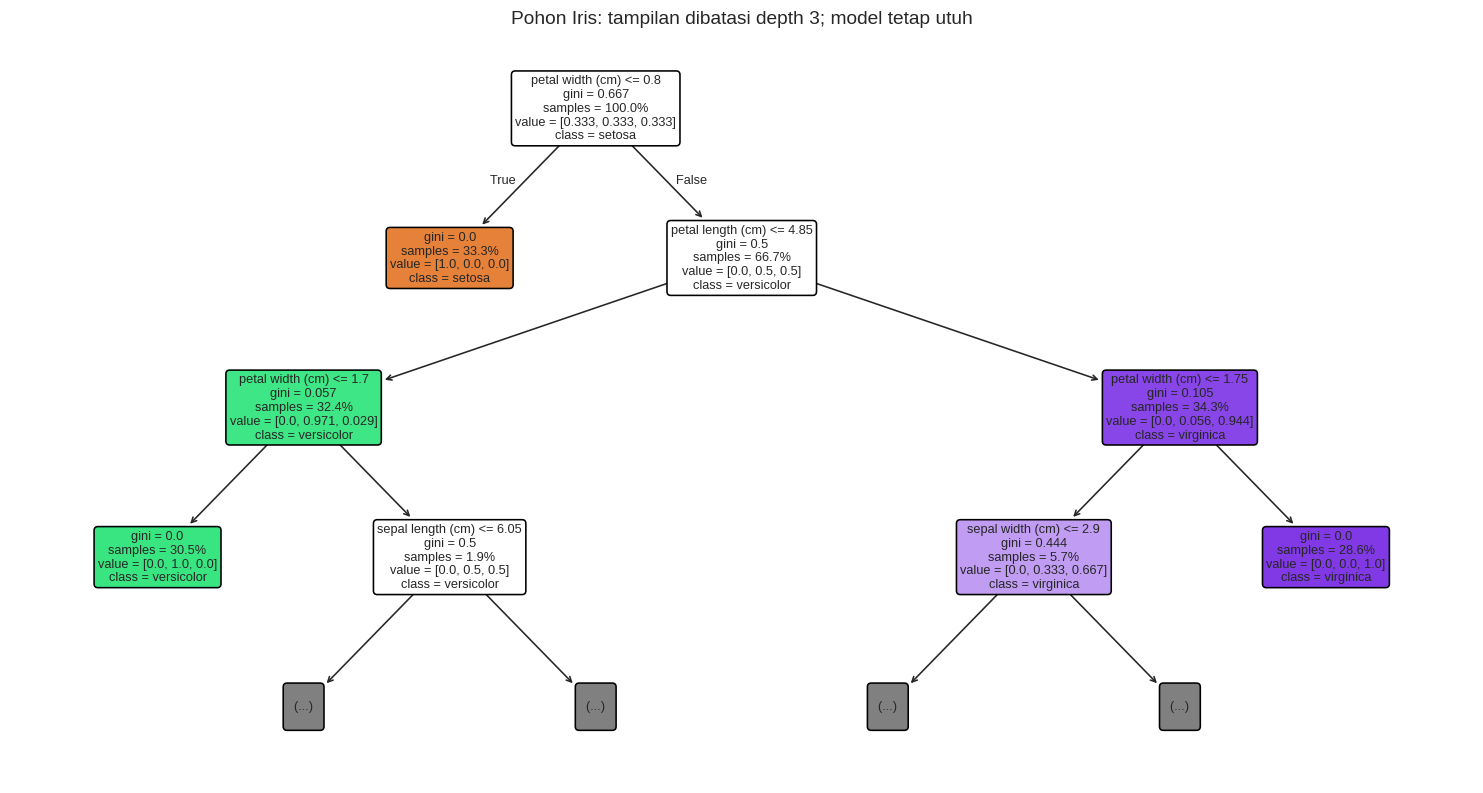

In [2]:
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_digits
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay
iris=load_iris(); audit_numeric(iris.data,iris.target,'Iris')
Xt,Xv,yt,yv=train_test_split(iris.data,iris.target,test_size=.3,stratify=iris.target,random_state=SEED)
cv=StratifiedKFold(5,shuffle=True,random_state=SEED)
tree=DecisionTreeClassifier(random_state=SEED).fit(Xt,yt)
print({'depth':tree.get_depth(),'leaves':tree.get_n_leaves(),'training_accuracy':tree.score(Xt,yt),**metrics(yv,tree.predict(Xv))})
report(yv,tree.predict(Xv),list(iris.target_names))
fig,ax=plt.subplots(figsize=(13,7))
plot_tree(tree,feature_names=iris.feature_names,class_names=list(iris.target_names),max_depth=3,
    filled=True,rounded=True,proportion=True,fontsize=8,ax=ax)
ax.set_title('Pohon Iris: tampilan dibatasi depth 3; model tetap utuh')
plt.tight_layout(); plt.show()

## 2. Bagging dan Random Forest
**Bagging** melatih banyak model pada bootstrap sample (sampling dengan pengembalian) lalu menggabungkan prediksi. Sampel training suatu pohon dapat berulang; sekitar 36,8% observasi tidak masuk bootstrap pohon tersebut ketika ukuran bootstrap sama dengan n. Observasi itu dapat dipakai untuk out-of-bag (OOB) evaluation. OOB tetap berasal dari training pool dan bukan pengganti evaluasi eksternal.

Jika pohon terlalu mirip, averaging kurang efektif. Random Forest menambahkan pengacakan subset fitur di setiap split (`max_features`) agar korelasi antar-pohon menurun. Lebih banyak pohon biasanya menstabilkan hasil dengan biaya waktu dan memori lebih besar; tidak otomatis menyelesaikan bias sistematis.

`feature_importances_` mengukur penurunan impurity terakumulasi dan dapat bias terhadap fitur yang menyediakan banyak kandidat split. **Permutation importance** mengukur penurunan skor setelah satu fitur diacak; hasil bergantung metrik dan dataset. Fitur berkorelasi dapat saling menggantikan sehingga importance masing-masing terlihat rendah. Analisis test di sini hanya interpretasi akhir; tidak dipakai menghapus fitur lalu mengevaluasi ulang test yang sama.

,model,OOB training,accuracy,balanced_accuracy,macro_f1
0,Bagging,0.9524,0.9333,0.9333,0.9333
1,Random Forest,0.9619,0.9333,0.9333,0.9333


,feature,impurity,permutation_mean,permutation_std
0,sepal length (cm),0.0863,-0.0167,0.0096
1,sepal width (cm),0.0229,-0.0089,0.0109
2,petal length (cm),0.4682,0.2667,0.0439
3,petal width (cm),0.4226,0.3167,0.0688


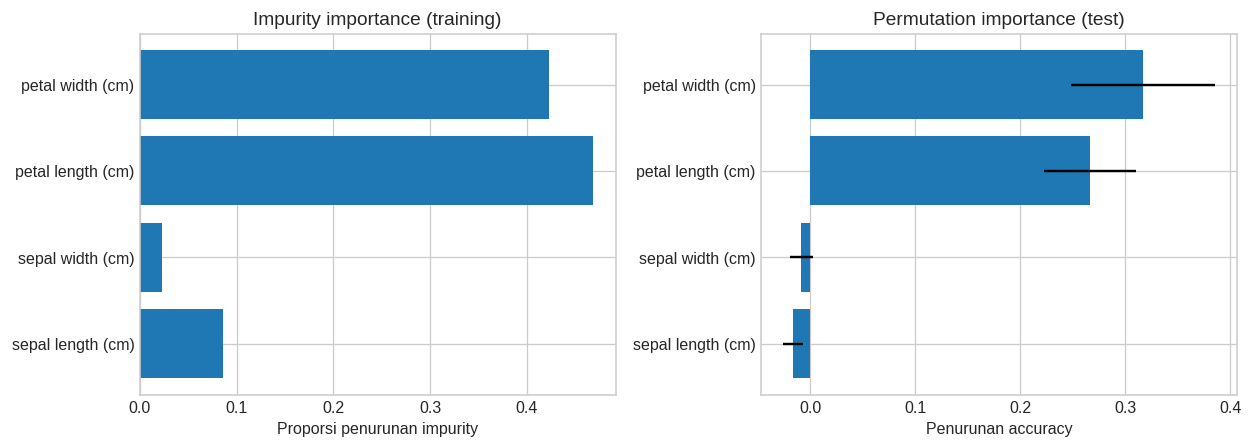

In [3]:
bag=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=SEED),n_estimators=100,
    bootstrap=True,oob_score=True,random_state=SEED,n_jobs=1).fit(Xt,yt)
rf=RandomForestClassifier(n_estimators=100,max_features='sqrt',oob_score=True,random_state=SEED,n_jobs=1).fit(Xt,yt)
display(pd.DataFrame([{'model':name,'OOB training':m.oob_score_,**metrics(yv,m.predict(Xv))}
    for name,m in [('Bagging',bag),('Random Forest',rf)]]))
pi=permutation_importance(rf,Xv,yv,n_repeats=20,random_state=SEED,scoring='accuracy',n_jobs=1)
importance=pd.DataFrame({'feature':iris.feature_names,'impurity':rf.feature_importances_,
    'permutation_mean':pi.importances_mean,'permutation_std':pi.importances_std})
display(importance)
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].barh(iris.feature_names,rf.feature_importances_); axes[0].set(title='Impurity importance (training)',xlabel='Proporsi penurunan impurity')
axes[1].barh(iris.feature_names,pi.importances_mean,xerr=pi.importances_std); axes[1].set(title='Permutation importance (test)',xlabel='Penurunan accuracy')
plt.tight_layout(); plt.show()

## 3. Gradient boosting
Boosting menambahkan weak learners secara **berurutan** untuk memperbaiki objective yang masih buruk. Bentuk umum pembaruan:
$$F_m(x)=F_{m-1}(x)+\eta h_m(x),$$
dengan $h_m$ dipelajari dari arah negative gradient loss dan $\eta$ adalah learning rate. Untuk klasifikasi, objective terkait log-loss; penjelasan “memodelkan residual” paling langsung berlaku pada squared-error regression.

Learning rate kecil membutuhkan lebih banyak tahap. Depth, jumlah estimator, learning rate dan subsampling saling berinteraksi. Sumber memakai 1.000 estimator dan learning rate 0,2 pada Iris; kita jalankan untuk reproduksi, tetapi tidak menganggap konfigurasi itu optimal. Evaluasi training yang sempurna tidak membuktikan generalisasi sempurna.

{'fit_seconds': 6.5, 'training_accuracy': 1.0, 'accuracy': 0.9555555555555556, 'balanced_accuracy': np.float64(0.9555555555555556), 'macro_f1': 0.9555555555555556}


,precision,recall,f1-score,support
setosa,1.0000,1.0000,1.0000,15.0
versicolor,0.9333,0.9333,0.9333,15.0
virginica,0.9333,0.9333,0.9333,15.0
macro avg,0.9556,0.9556,0.9556,45.0
weighted avg,0.9556,0.9556,0.9556,45.0


Overall accuracy: 0.9556 (n=45)


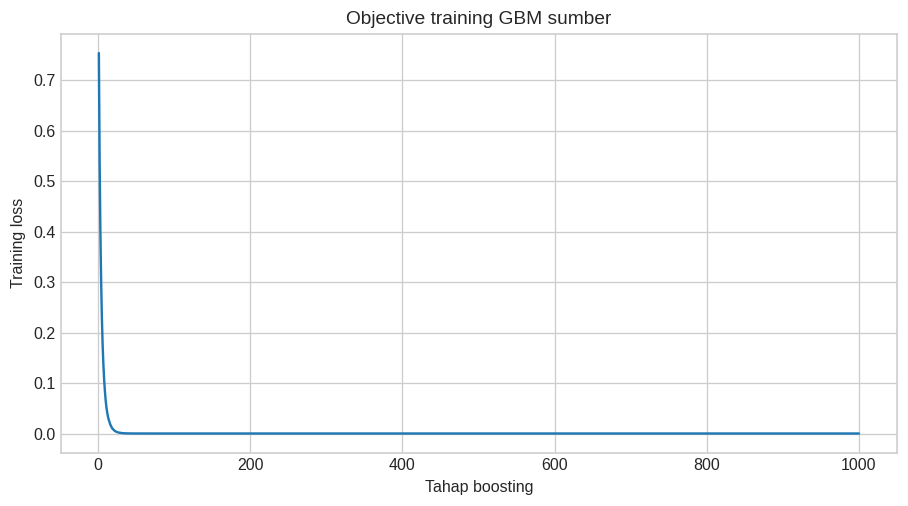

In [4]:
gb_source=GradientBoostingClassifier(n_estimators=1000,learning_rate=.2,random_state=SEED)
t0=time.perf_counter(); gb_source.fit(Xt,yt); source_seconds=time.perf_counter()-t0
print({'fit_seconds':round(source_seconds,3),'training_accuracy':gb_source.score(Xt,yt),**metrics(yv,gb_source.predict(Xv))})
report(yv,gb_source.predict(Xv),list(iris.target_names))
fig,ax=plt.subplots(); ax.plot(np.arange(1,len(gb_source.train_score_)+1),gb_source.train_score_)
ax.set(xlabel='Tahap boosting',ylabel='Training loss',title='Objective training GBM sumber')
plt.tight_layout(); plt.show()

## 4. Hyperparameter tuning di training-CV
Grid sumber mencakup jumlah estimator 50/100/150, depth 3/4/5 dan learning rate 0,01/0,1/0,2. Total 27 kandidat × 5 fold = 135 fitting, ditambah refit kandidat terbaik. Scoring yang dipilih adalah accuracy pada Iris yang relatif seimbang.

Heatmap menggunakan **learning rate milik kandidat terbaik CV** yang ditahan konstan. Merata-ratakan skor lintas learning rate akan membuat setiap kotak tidak lagi mewakili satu konfigurasi. Skor test diperiksa sesudah seluruh pemilihan selesai; tidak dipakai untuk memperluas grid.

Best CV parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50} score: 0.9428571428571427
Final test: {'accuracy': 0.9555555555555556, 'balanced_accuracy': np.float64(0.9555555555555556), 'macro_f1': 0.9553571428571429}


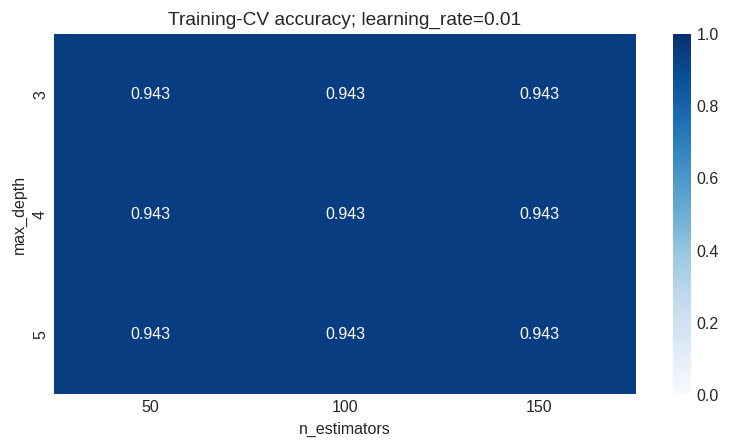

In [5]:
params={'n_estimators':[50,100,150],'max_depth':[3,4,5],'learning_rate':[.01,.1,.2]}
search=GridSearchCV(GradientBoostingClassifier(random_state=SEED),params,cv=cv,scoring='accuracy',n_jobs=1,error_score='raise').fit(Xt,yt)
print('Best CV parameters:',search.best_params_,'score:',search.best_score_)
print('Final test:',metrics(yv,search.predict(Xv)))
results=pd.DataFrame(search.cv_results_)
rate=search.best_params_['learning_rate']
slice_=results[results.param_learning_rate==rate]
heat=slice_.pivot(index='param_max_depth',columns='param_n_estimators',values='mean_test_score')
fig,ax=plt.subplots(figsize=(7,4)); sns.heatmap(heat.astype(float),annot=True,fmt='.3f',cmap='Blues',vmin=0,vmax=1,ax=ax)
ax.set(title=f'Training-CV accuracy; learning_rate={rate}',xlabel='n_estimators',ylabel='max_depth')
plt.tight_layout(); plt.show()

## 5. Membandingkan ensemble dan stacking
Random Forest menggabungkan pohon melalui averaging, gradient boosting menambah model berurutan, sedangkan stacking mempelajari cara menggabungkan prediksi base learners. Meta-learner harus dilatih menggunakan prediksi **out-of-fold** base learners agar tidak hanya mempelajari prediksi yang terlalu optimistis dari data yang sudah dilihat. `StackingClassifier(cv=5)` mengerjakan prosedur tersebut untuk training meta-model, lalu melatih ulang base learners pada seluruh training set.

Stacking tidak dijamin mengungguli model tunggal. Pada test Iris yang hanya 45 sampel, satu kesalahan mengubah accuracy sekitar 2,22 poin persentase. Berikut perbandingan kandidat yang telah ditentukan; hasilnya bersifat deskriptif dan tidak digunakan untuk memilih model melalui test.

,fit_seconds,accuracy,balanced_accuracy,macro_f1
model,,,,
Dummy,0.0007,0.3333,0.3333,0.1667
RF,0.1679,0.9333,0.9333,0.9333
GB,0.3325,0.9333,0.9333,0.9333
Stacking,2.9788,0.9556,0.9556,0.9556


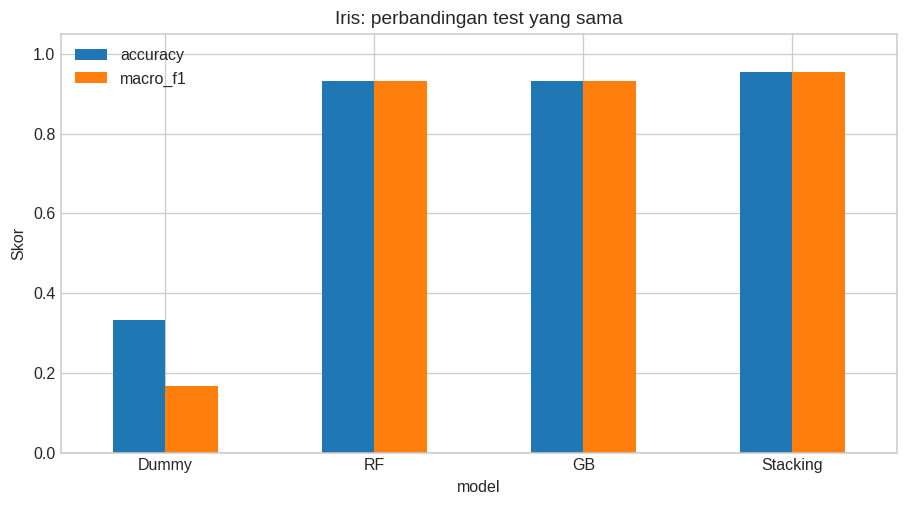

In [6]:
rf_comp=RandomForestClassifier(n_estimators=100,random_state=SEED,n_jobs=1)
gb_comp=GradientBoostingClassifier(n_estimators=100,random_state=SEED)
stack=StackingClassifier(estimators=[('rf',clone(rf_comp)),('gb',clone(gb_comp))],
    final_estimator=LogisticRegression(max_iter=2000,random_state=SEED),cv=cv,n_jobs=1)
models={'Dummy':DummyClassifier(strategy='most_frequent'),'RF':rf_comp,'GB':gb_comp,'Stacking':stack}
comparison=[]
for name,m in models.items():
    t0=time.perf_counter(); m.fit(Xt,yt)
    comparison.append({'model':name,'fit_seconds':time.perf_counter()-t0,**metrics(yv,m.predict(Xv))})
comp=pd.DataFrame(comparison).set_index('model'); display(comp)
fig,ax=plt.subplots(); comp[['accuracy','macro_f1']].plot.bar(ax=ax,ylim=(0,1.05),rot=0)
ax.set(title='Iris: perbandingan test yang sama',ylabel='Skor'); plt.tight_layout(); plt.show()

## 6. Latihan 1 — decision tree pada Wine
Wine memiliki 178 sampel, 13 fitur kimia, dan tiga kelas. Gunakan split 70/30 dengan stratifikasi agar kelas minoritas terwakili. Tree tidak membutuhkan standardisasi. Hasil training dan test diperlihatkan bersama untuk melihat kemungkinan overfitting. Confusion matrix memperjelas kelas yang tertukar.

Wine {'shape': (178, 13), 'missing': 0, 'duplicate_rows': 0, 'all_finite': True}


,jumlah
0,59
1,71
2,48


Train: 1.0 Test: {'accuracy': 0.8518518518518519, 'balanced_accuracy': np.float64(0.8640211640211639), 'macro_f1': 0.8522924838714313}


,precision,recall,f1-score,support
class_0,0.8947,0.9444,0.9189,18.0
class_1,0.8824,0.7143,0.7895,21.0
class_2,0.7778,0.9333,0.8485,15.0
macro avg,0.8516,0.8640,0.8523,54.0
weighted avg,0.8574,0.8519,0.8490,54.0


Overall accuracy: 0.8519 (n=54)


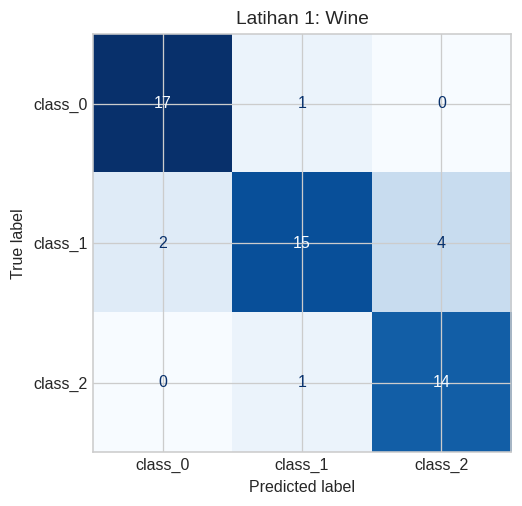

In [7]:
wine=load_wine(); audit_numeric(wine.data,wine.target,'Wine')
Wt,Wv,wt,wv=train_test_split(wine.data,wine.target,test_size=.3,stratify=wine.target,random_state=SEED)
wine_tree=DecisionTreeClassifier(random_state=SEED).fit(Wt,wt)
print('Train:',wine_tree.score(Wt,wt),'Test:',metrics(wv,wine_tree.predict(Wv)))
report(wv,wine_tree.predict(Wv),list(wine.target_names))
fig,ax=plt.subplots(); ConfusionMatrixDisplay.from_estimator(wine_tree,Wv,wv,display_labels=wine.target_names,cmap='Blues',colorbar=False,ax=ax)
ax.set_title('Latihan 1: Wine'); plt.tight_layout(); plt.show()

## 7. Latihan 2 — Random Forest grid pada Breast Cancer
Grid sumber menala jumlah pohon, maximum depth dan subset fitur. Pada data ini jumlah kelas berbeda; balanced accuracy dipakai untuk seleksi dan laporan tiap kelas tetap dicetak. Malignant adalah kelas 0. Tidak ada penghapusan “outlier” secara otomatis karena observasi ekstrem dapat menjadi bagian penting dari target.

In [8]:
c=load_breast_cancer()
Ct,Cv,ct,cv_y=train_test_split(c.data,c.target,test_size=.3,stratify=c.target,random_state=SEED)
rf_grid={'n_estimators':[50,100,150],'max_depth':[3,5,7],'max_features':['sqrt','log2']}
rf_search=GridSearchCV(RandomForestClassifier(random_state=SEED,n_jobs=1),rf_grid,cv=cv,
    scoring='balanced_accuracy',n_jobs=1,error_score='raise').fit(Ct,ct)
print('Best params:',rf_search.best_params_,'CV balanced accuracy:',rf_search.best_score_)
print('Test:',metrics(cv_y,rf_search.predict(Cv)))
report(cv_y,rf_search.predict(Cv),list(c.target_names))

Best params: {'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 50} CV balanced accuracy: 0.9595402298850575
Test: {'accuracy': 0.9590643274853801, 'balanced_accuracy': np.float64(0.9578709112149533), 'macro_f1': 0.9564362921716345}


,precision,recall,f1-score,support
malignant,0.9385,0.9531,0.9457,64.0
benign,0.9717,0.9626,0.9671,107.0
macro avg,0.9551,0.9579,0.9564,171.0
weighted avg,0.9593,0.9591,0.9591,171.0


Overall accuracy: 0.9591 (n=171)


## 8. Latihan 3 — RF vs GB pada Digits
Digits berisi citra 8×8 yang diperlakukan sebagai 64 fitur intensitas. Latihan membandingkan RF dan GB dengan 100 estimator pada split yang sama, sesuai sumber. Pada multiclass, gradient boosting dapat melatih beberapa pohon per tahap sehingga waktu model tidak sebanding hanya dari angka `n_estimators`. Waktu di bawah adalah hasil pada satu lingkungan, bukan benchmark perangkat universal.

Macro F1 membantu melihat apakah performa baik merata di semua digit. Jangan memilih model hanya dari angka accuracy terbesar pada satu test kecil; pilihan operasional juga perlu biaya prediksi, variasi CV, dan data yang mewakili penggunaan sebenarnya.

Digits {'shape': (1797, 64), 'missing': 0, 'duplicate_rows': 0, 'all_finite': True}


,jumlah
0,178
1,182
2,177
3,183
4,181
5,182
6,181
7,179
8,174
9,180


,fit_seconds,accuracy,balanced_accuracy,macro_f1
model,,,,
RF,0.4099,0.9722,0.9720,0.9721
GB,8.1343,0.9648,0.9649,0.9649


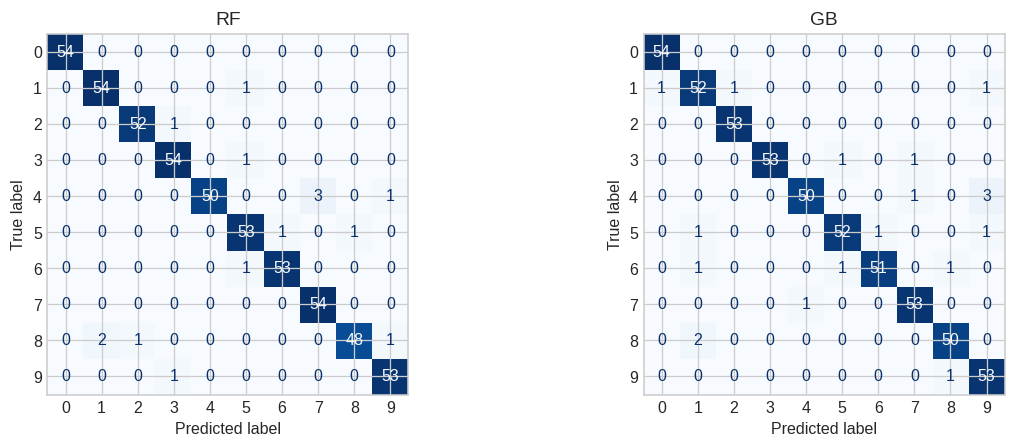

**Analisis hasil:** perbandingan di atas mencatat skor dan biaya fitting pada split yang identik. Selisih terhadap training, kesalahan per digit, serta waktu fitting perlu dibaca bersama. Semua konfigurasi latihan ditetapkan sebelum test dinilai.

In [9]:
digits=load_digits(); audit_numeric(digits.data,digits.target,'Digits')
Dt,Dv,dt,dv=train_test_split(digits.data,digits.target,test_size=.3,stratify=digits.target,random_state=SEED)
digit_models={'RF':RandomForestClassifier(n_estimators=100,random_state=SEED,n_jobs=1),
              'GB':GradientBoostingClassifier(n_estimators=100,learning_rate=.1,random_state=SEED)}
digit_rows=[]
for name,m in digit_models.items():
    t0=time.perf_counter(); m.fit(Dt,dt)
    digit_rows.append({'model':name,'fit_seconds':time.perf_counter()-t0,**metrics(dv,m.predict(Dv))})
digit_results=pd.DataFrame(digit_rows).set_index('model'); display(digit_results)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,(name,m) in zip(axes,digit_models.items()):
    ConfusionMatrixDisplay.from_predictions(dv,m.predict(Dv),ax=ax,cmap='Blues',colorbar=False,values_format='d')
    ax.set_title(name)
plt.tight_layout(); plt.show()
display(Markdown('**Analisis hasil:** perbandingan di atas mencatat skor dan biaya fitting pada split yang identik. '
    'Selisih terhadap training, kesalahan per digit, serta waktu fitting perlu dibaca bersama. Semua konfigurasi latihan ditetapkan sebelum test dinilai.'))

## Ringkasan chapter
Decision tree mudah dijelaskan lewat aturan tetapi rentan overfitting. Bagging dan Random Forest mengurangi varians dengan menggabungkan model yang cukup beragam. Boosting memperbaiki objective secara bertahap; stacking mempelajari penggabungan dari prediksi out-of-fold. Evaluasi yang benar memisahkan tuning dari test dan menempatkan feature importance sebagai penjelasan model, bukan klaim kausal.

## Refleksi untuk dikerjakan sendiri
1. Mengapa bootstrap dan pengacakan fitur dapat mengurangi korelasi antarpohon?
2. Mengapa 100 tahap gradient boosting multiclass dapat lebih mahal daripada 100 pohon RF?
3. Apa yang salah jika meta-model stacking dilatih dari prediksi base model atas training yang sama?
4. Mengapa impurity importance tinggi belum berarti fitur menyebabkan perubahan target?

## Referensi dan atribusi
- John Sukup. *scikit-learn Cookbook*, Third Edition. Packt Publishing, 2025. Kode pendamping Chapter 8 dan solusi latihan: [repository resmi](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500).
- [Decision trees](https://scikit-learn.org/1.8/modules/tree.html).
- [Ensemble methods](https://scikit-learn.org/1.8/modules/ensemble.html).
- [Permutation importance](https://scikit-learn.org/1.8/modules/permutation_importance.html).
- Kode sumber pendamping berlisensi MIT; teks lisensi dipertahankan pada `THIRD_PARTY_NOTICES.md`. Penjelasan, koreksi metodologi, dan eksperimen tambahan pada notebook ini merupakan adaptasi belajar berbantuan AI. Baca, jalankan ulang, dan tulis refleksi pribadi sebelum menyerahkan tugas; jangan menyatakan bagian berbantuan AI sebagai pekerjaan mandiri tanpa mengikuti kebijakan kelas.